In [101]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

In [102]:
df = pd.read_csv(r"D:\Projects\Customer_Churn_Prediction\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [103]:
df.head(20)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [104]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [105]:
df['Churn'] = pd.to_numeric(df['Churn'].replace({'Yes': 1, 'No': 0}))

In [106]:
correlations = df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)
print(correlations)

Churn             1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
tenure           -0.352229
Name: Churn, dtype: float64


In [107]:
df.drop(columns=['customerID'], inplace= True)

In [108]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [109]:
df['OnlineBackup'].values.unique()

<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

In [110]:
df['gender'] = pd.to_numeric(df['gender'].replace({'Female': 0, 'Male': 1}))
df['Partner']= pd.to_numeric(df['Partner'].replace({'Yes': 1, 'No': 0}))
df['Dependents']= pd.to_numeric(df['Dependents'].replace({'Yes': 1, 'No': 0}))
df['PhoneService']= pd.to_numeric(df['PhoneService'].replace({'Yes': 1, 'No': 0}))
df['MultipleLines']= pd.to_numeric(df['MultipleLines'].replace({'Yes': 1, 'No': 0, 'No phone service': 2}))
df['OnlineSecurity']= pd.to_numeric(df['OnlineSecurity'].replace({'Yes': 1, 'No': 0, 'No internet service': 2}))
df['OnlineBackup']= pd.to_numeric(df['OnlineBackup'].replace({'Yes': 1, 'No': 0, 'No internet service': 2}))
df['DeviceProtection'] = pd.to_numeric(df['DeviceProtection'].replace(
    {'Yes': 1, 'No': 0, 'No internet service': 2}))
df['TechSupport'] = pd.to_numeric(df['TechSupport'].replace(
    {'Yes': 1, 'No': 0, 'No internet service': 2}))
df['StreamingTV'] = pd.to_numeric(
    df['StreamingTV'].replace({'Yes': 1, 'No': 0, 'No internet service': 2}))
df['StreamingMovies'] = pd.to_numeric(
    df['StreamingMovies'].replace({'Yes': 1, 'No': 0, 'No internet service': 2}))
df['PaperlessBilling'] = pd.to_numeric(
    df['PaperlessBilling'].replace({'Yes': 1, 'No': 0}))

In [111]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,2,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.5,0
2,1,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,2,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [112]:
df['Contract'].values.unique()

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [113]:
contract_df= pd.get_dummies(df['Contract'], prefix='Contract', dtype=int)

In [114]:
df= df.join(contract_df)

In [115]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Contract_Month-to-month,Contract_One year,Contract_Two year
0,0,0,1,0,1,0,2,DSL,0,1,...,0,Month-to-month,1,Electronic check,29.85,29.85,0,1,0,0
1,1,0,0,0,34,1,0,DSL,1,0,...,0,One year,0,Mailed check,56.95,1889.5,0,0,1,0
2,1,0,0,0,2,1,0,DSL,1,1,...,0,Month-to-month,1,Mailed check,53.85,108.15,1,1,0,0
3,1,0,0,0,45,0,2,DSL,1,0,...,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,0,1,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,...,0,Month-to-month,1,Electronic check,70.70,151.65,1,1,0,0


In [116]:
df.drop(columns= ['Contract'], inplace= True)

In [117]:
internetservice = pd.get_dummies(df['InternetService'], prefix='InternetService', dtype=int)

In [118]:
df= df.join(internetservice)

In [119]:
df.drop(columns=['InternetService'], inplace=True)

In [120]:
df['PaymentMethod'].values.unique()

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [121]:
payment = pd.get_dummies(
    df['PaymentMethod'], prefix='PaymentMethod', dtype=int)

In [122]:
df= df.join(payment)

In [123]:
df.drop(columns=['PaymentMethod'], inplace= True)

In [124]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Month-to-month,Contract_One year,Contract_Two year,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,2,0,1,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,0,1,0,1,0,0,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,45,0,2,1,0,1,...,0,1,0,1,0,0,1,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,1,0,0,0,1,0,0,0,1,0


In [125]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'].str.strip(),
    errors='coerce'
)

In [126]:
from sklearn.preprocessing import StandardScaler
ss= StandardScaler()
df['TotalCharges']= ss.fit_transform(df[['TotalCharges']])

In [127]:
df.dropna(inplace= True)

In [128]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Month-to-month,Contract_One year,Contract_Two year,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,...,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.504693,0.162400,0.482509,0.298493,32.421786,0.903299,0.615330,0.718857,0.777162,0.776166,...,0.551052,0.209329,0.239619,0.343572,0.440273,0.216155,0.219283,0.216297,0.336320,0.228100
std,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,0.655867,0.796556,0.778188,0.778542,...,0.497422,0.406858,0.426881,0.474934,0.496455,0.411650,0.413790,0.411748,0.472483,0.419637
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,2.000000,2.000000,2.000000,2.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [129]:
# Tenure buckets — churn behavior often isn't linear with tenure
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
                            labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr'])

# New customer flag — new customers churn at very different rates
df['is_new_customer'] = (df['tenure'] <= 6).astype(int)

In [130]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Two year,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group,is_new_customer
0,0,0,1,0,1,0,2,0,1,0,...,0,1,0,0,0,0,1,0,0-1yr,1
1,1,0,0,0,34,1,0,1,0,1,...,0,1,0,0,0,0,0,1,2-4yr,0
2,1,0,0,0,2,1,0,1,1,0,...,0,1,0,0,0,0,0,1,0-1yr,1
3,1,0,0,0,45,0,2,1,0,1,...,0,1,0,0,1,0,0,0,2-4yr,0
4,0,0,0,0,2,1,0,0,0,0,...,0,0,1,0,0,0,1,0,0-1yr,1


Charge-based ratios

In [131]:
# Average charge per month of tenure — catches pricing anomalies
df['avg_monthly_charge'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

# Difference between current monthly charge and their historical average
df['charge_diff'] = df['MonthlyCharges'] - df['avg_monthly_charge']

Service count features

In [132]:
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['total_services'] = df[service_cols].sum(axis=1)

# Customers with zero add-on services vs many — often correlates with churn
df['no_addon_services'] = (df[['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                               'TechSupport']].sum(axis=1) == 0).astype(int)

In [133]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group,is_new_customer,avg_monthly_charge,charge_diff,total_services,no_addon_services
0,0,0,1,0,1,0,2,0,1,0,...,0,0,1,0,0-1yr,1,-0.994194,30.844194,3,0
1,1,0,0,0,34,1,0,1,0,1,...,0,0,0,1,2-4yr,0,-0.005110,56.955110,3,0
2,1,0,0,0,2,1,0,1,1,0,...,0,0,0,1,0-1yr,1,-0.479825,54.329825,3,0
3,1,0,0,0,45,0,2,1,0,1,...,1,0,0,0,2-4yr,0,-0.004339,42.304339,5,0
4,0,0,0,0,2,1,0,0,0,0,...,0,0,1,0,0-1yr,1,-0.470229,71.170229,1,1


In [134]:
tenuredf = pd.get_dummies(
    df['tenure_group'], prefix='tenuregroup', dtype=int)
df= df.join(tenuredf)

In [135]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,tenure_group,is_new_customer,avg_monthly_charge,charge_diff,total_services,no_addon_services,tenuregroup_0-1yr,tenuregroup_1-2yr,tenuregroup_2-4yr,tenuregroup_4-6yr
0,0,0,1,0,1,0,2,0,1,0,...,0-1yr,1,-0.994194,30.844194,3,0,1,0,0,0
1,1,0,0,0,34,1,0,1,0,1,...,2-4yr,0,-0.005110,56.955110,3,0,0,0,1,0
2,1,0,0,0,2,1,0,1,1,0,...,0-1yr,1,-0.479825,54.329825,3,0,1,0,0,0
3,1,0,0,0,45,0,2,1,0,1,...,2-4yr,0,-0.004339,42.304339,5,0,0,0,1,0
4,0,0,0,0,2,1,0,0,0,0,...,0-1yr,1,-0.470229,71.170229,1,1,1,0,0,0


In [136]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 37 columns):
 #   Column                                   Non-Null Count  Dtype   
---  ------                                   --------------  -----   
 0   gender                                   7032 non-null   int64   
 1   SeniorCitizen                            7032 non-null   int64   
 2   Partner                                  7032 non-null   int64   
 3   Dependents                               7032 non-null   int64   
 4   tenure                                   7032 non-null   int64   
 5   PhoneService                             7032 non-null   int64   
 6   MultipleLines                            7032 non-null   int64   
 7   OnlineSecurity                           7032 non-null   int64   
 8   OnlineBackup                             7032 non-null   int64   
 9   DeviceProtection                         7032 non-null   int64   
 10  TechSupport                              7032 non-nu

In [137]:
df.drop(columns= ['tenure_group'], inplace= True)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaymentMethod_Mailed check,is_new_customer,avg_monthly_charge,charge_diff,total_services,no_addon_services,tenuregroup_0-1yr,tenuregroup_1-2yr,tenuregroup_2-4yr,tenuregroup_4-6yr
gender,1.000000,-0.001819,-0.001379,0.010349,0.005285,-0.007515,0.000084,-0.004365,-0.002978,0.004526,...,0.013199,-0.001328,-0.011982,-0.013695,-0.001220,0.007811,-0.001050,-0.000649,-0.010516,0.010985
SeniorCitizen,-0.001819,1.000000,0.016957,-0.210550,0.015683,0.008392,0.100120,-0.210546,-0.152380,-0.156700,...,-0.152987,-0.020604,0.030137,0.220059,-0.174025,0.106582,-0.027713,0.001860,0.020383,0.007768
Partner,-0.001379,0.016957,1.000000,0.452269,0.381912,0.018397,0.090774,0.081078,0.086346,0.093391,...,-0.096948,-0.276653,0.276609,0.095402,0.108392,-0.168337,-0.305061,-0.048481,0.028468,0.313793
Dependents,0.010349,-0.210550,0.452269,1.000000,0.163386,-0.001078,-0.017333,0.188889,0.160845,0.154819,...,0.056448,-0.137402,0.122959,-0.113754,0.178794,-0.140849,-0.145379,-0.001459,0.024645,0.123195
tenure,0.005285,0.015683,0.381912,0.163386,1.000000,0.007877,0.243214,0.147575,0.180896,0.180895,...,-0.232181,-0.626137,0.599880,0.241682,0.218876,-0.374454,-0.754330,-0.236673,0.083153,0.852883
PhoneService,-0.007515,0.008392,0.018397,-0.001078,0.007877,1.000000,-0.690813,0.125544,0.149932,0.138938,...,-0.004463,-0.005739,0.012046,0.248450,0.128128,-0.010617,-0.006950,0.012307,-0.014778,0.010858
MultipleLines,0.000084,0.100120,0.090774,-0.017333,0.243214,-0.690813,1.000000,-0.235077,-0.210051,-0.200400,...,-0.167426,-0.172529,0.187432,0.144657,-0.133258,-0.024048,-0.192038,-0.044937,0.031159,0.196554
OnlineSecurity,-0.004365,-0.210546,0.081078,0.188889,0.147575,0.125544,-0.235077,1.000000,0.751312,0.748684,...,0.285061,-0.098669,0.052684,-0.622363,0.871186,-0.423102,-0.109129,-0.013722,-0.002071,0.120525
OnlineBackup,-0.002978,-0.152380,0.086346,0.160845,0.180896,0.149932,-0.210051,0.751312,1.000000,0.740244,...,0.231894,-0.108957,0.077385,-0.539616,0.872687,-0.468216,-0.134168,-0.033063,0.007510,0.151401
DeviceProtection,0.004526,-0.156700,0.093391,0.154819,0.180895,0.138938,-0.200400,0.748684,0.740244,1.000000,...,0.223777,-0.123075,0.085168,-0.514513,0.893017,-0.467404,-0.137994,-0.028895,0.020851,0.140051


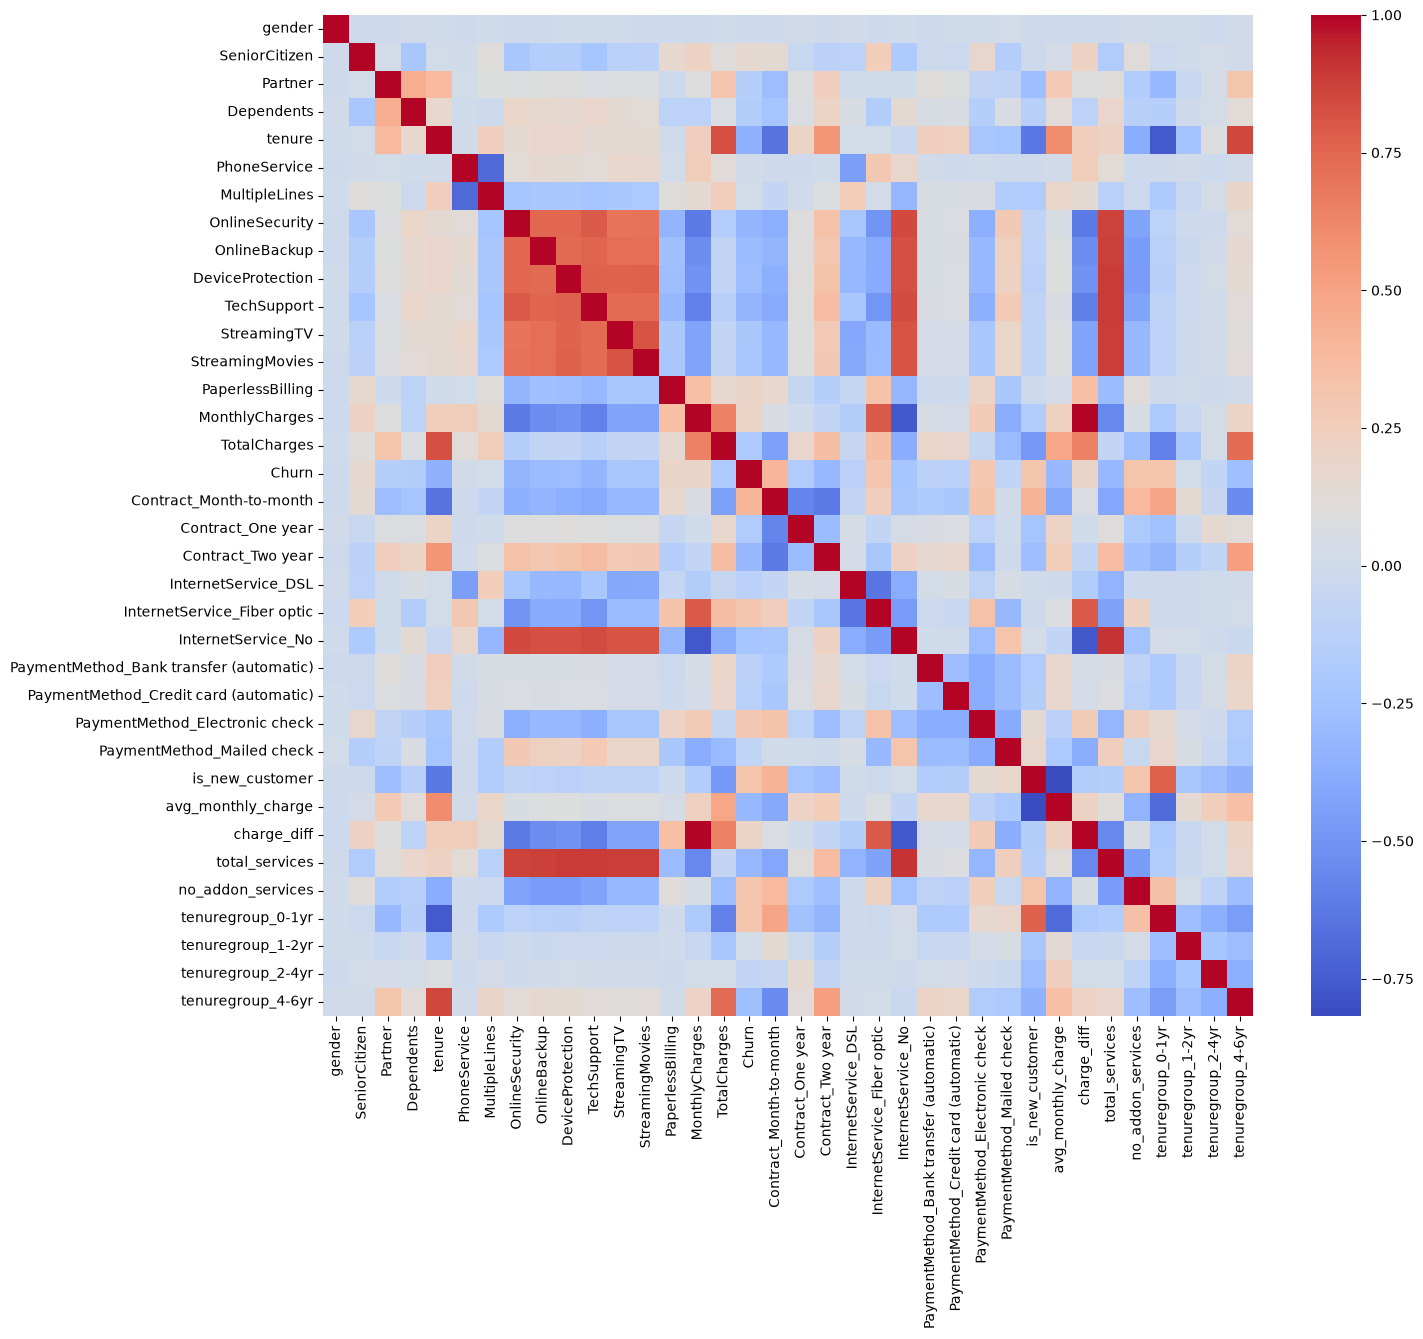

In [143]:
from IPython.display import display
corr = df.corr()
display(corr)
plt.figure(figsize=(15, 13))
sns.heatmap(data=corr, cmap='coolwarm')
plt.show()

Solving correlation problem

In [145]:
threshold_high = 0.85  # high correlation with each other
threshold_low = 0.05   # low correlation with target

corr_matrix = df.corr().abs()

# high correlation columns with each other
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [col for col in upper.columns if any(upper[col] > threshold_high)]

# low correlation columns with target
low_impact = corr_matrix['Churn'][corr_matrix['Churn']
                                      < threshold_low].index.tolist()


to_drop = list(set(high_corr + low_impact))
print("the columns removed:", to_drop)

df.drop(columns=to_drop, inplace=True)

the columns removed: ['total_services', 'MultipleLines', 'tenuregroup_4-6yr', 'tenuregroup_1-2yr', 'gender', 'PhoneService', 'charge_diff']


,SeniorCitizen,Partner,Dependents,tenure,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,...,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,is_new_customer,avg_monthly_charge,no_addon_services,tenuregroup_0-1yr,tenuregroup_2-4yr
SeniorCitizen,1.000000,0.016957,-0.210550,0.015683,-0.210546,-0.152380,-0.156700,-0.223438,-0.129721,-0.120658,...,-0.182519,-0.016235,-0.024359,0.171322,-0.152987,-0.020604,0.030137,0.106582,-0.027713,0.020383
Partner,0.016957,1.000000,0.452269,0.381912,0.081078,0.086346,0.093391,0.068277,0.079066,0.075310,...,-0.000286,0.111406,0.082327,-0.083207,-0.096948,-0.276653,0.276609,-0.168337,-0.305061,0.028468
Dependents,-0.210550,0.452269,1.000000,0.163386,0.188889,0.160845,0.154819,0.179176,0.138809,0.125086,...,0.138383,0.052369,0.061134,-0.149274,0.056448,-0.137402,0.122959,-0.140849,-0.145379,0.024645
tenure,0.015683,0.381912,0.163386,1.000000,0.147575,0.180896,0.180895,0.146727,0.138208,0.142143,...,-0.037529,0.243822,0.232800,-0.210197,-0.232181,-0.626137,0.599880,-0.374454,-0.754330,0.083153
OnlineSecurity,-0.210546,0.081078,0.188889,0.147575,1.000000,0.751312,0.748684,0.790951,0.701526,0.704672,...,0.844655,0.052438,0.067483,-0.357910,0.285061,-0.098669,0.052684,-0.423102,-0.109129,-0.002071
OnlineBackup,-0.152380,0.086346,0.160845,0.180896,0.751312,1.000000,0.740244,0.753752,0.720277,0.716388,...,0.825244,0.051950,0.057233,-0.301330,0.231894,-0.108957,0.077385,-0.468216,-0.134168,0.007510
DeviceProtection,-0.156700,0.093391,0.154819,0.180895,0.748684,0.740244,1.000000,0.767659,0.762742,0.766635,...,0.825541,0.049514,0.069858,-0.302989,0.223777,-0.123075,0.085168,-0.467404,-0.137994,0.020851
TechSupport,-0.223438,0.068277,0.179176,0.146727,0.790951,0.753752,0.767659,1.000000,0.737211,0.737126,...,0.843355,0.056183,0.068693,-0.360021,0.282558,-0.094934,0.057400,-0.425722,-0.107614,0.006180
StreamingTV,-0.129721,0.079066,0.138809,0.138208,0.701526,0.720277,0.762742,0.737211,1.000000,0.809507,...,0.814512,0.028227,0.027530,-0.214825,0.187032,-0.102933,0.073051,-0.313193,-0.111031,0.011659
StreamingMovies,-0.120658,0.075310,0.125086,0.142143,0.704672,0.716388,0.766635,0.737126,0.809507,1.000000,...,0.813546,0.030032,0.033009,-0.219809,0.185488,-0.107226,0.074570,-0.309525,-0.111945,0.009299


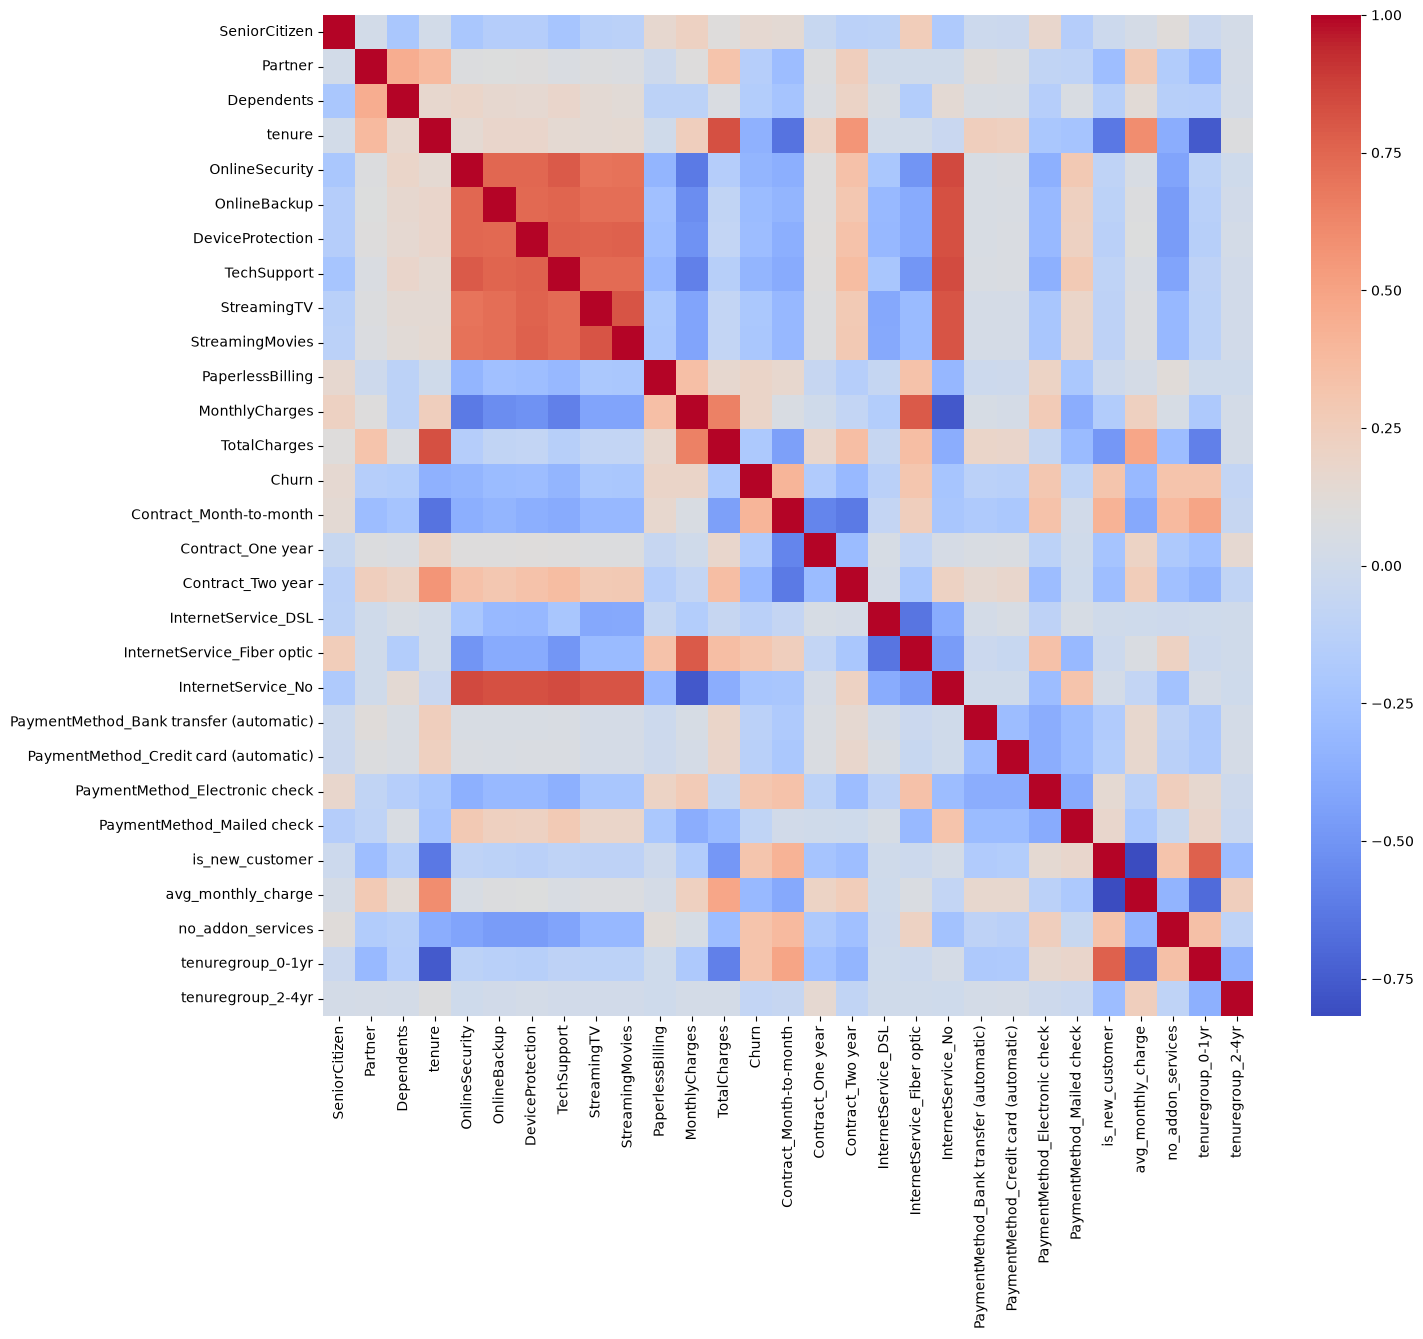

In [146]:
# Corr after removing columns
corr = df.corr()
display(corr)
plt.figure(figsize=(15, 13))
sns.heatmap(data=corr, cmap='coolwarm')
plt.show()

In [147]:
df.duplicated().sum()

np.int64(41)

In [149]:
df.drop_duplicates(inplace= True)

In [150]:
df.duplicated().sum()

np.int64(0)

In [151]:
x= df.drop(columns=['Churn'])
y= df['Churn']

In [152]:
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.2, random_state= 42)

In [153]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(x_train, y_train)
lg_pred = logreg.predict(x_test)
print(
    f"(Accuracy): {accuracy_score(y_test, lg_pred):.4f}\n")
print("F1_Score: ", f1_score(y_test,lg_pred))

(Accuracy): 0.7906

F1_Score:  0.5526717557251909


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(x_train, y_train)

# Prediction
rf_pred = rf_model.predict(x_test)

# Result
print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1_Score: ", f1_score(y_test,rf_pred))

=== Random Forest ===
Accuracy: 0.7984274481772695
F1_Score:  0.5688073394495413


In [157]:
# Parameter grid to search over
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [300, 400],          # Number of trees
    'max_depth': [10, 20, 25, None],         # Maximum depth of each tree
    # Minimum samples required to split a node
    'min_samples_split': [2, 5]
}

# Create a Random Forest model
rf = RandomForestClassifier(random_state=42)

# Grid search with 5-fold cross-validation, optimizing for F1 score
grid = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(x_train, y_train)               # Fit the grid search

# Display best parameters and best cross-validation F1 score
print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Best CV F1: 0.5706504424576705


In [158]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    eval_metric="logloss",
    random_state=42
)
xgb_model.fit(x_train, y_train)

# Prediction
xgb_pred = xgb_model.predict(x_test)

# Result
print("=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("F1_Score: ", f1_score(y_test, xgb_pred))

=== XGBoost ===
Accuracy: 0.777698355968549
F1_Score:  0.5499276410998553
